<a href="https://colab.research.google.com/github/Sarvamm/ds-ml-projects/blob/main/Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import random as rd
from pathlib import Path

#Data Viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#WordCloud
# from wordcloud import WordCloud

#Stats
import scipy.stats as stats

#Machine Learning
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
# from sklearn.svm import SVC

# import xgboost as xgb
# import lightgbm as lgb
# import catboost as cb

# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     mean_absolute_error,
#     mean_squared_error,
#     confusion_matrix,
#     classification_report
# )

################################################################################

# Configs

# Set the global theme to high-res and clean
#Themes: darkgrid, whitegrid, dark, white, ticks
#Palettes: deep, muted, bright, colorblind
#Context: paper, talk, poster, notebook
sns.set_theme(
    context= "paper",
    style="darkgrid",
    palette="muted")

plt.rcParams['figure.figsize'] = (6,3)   # Default plot size
plt.rcParams['figure.dpi'] = 150

RANDOM_STATE = 278453

In [61]:
#Paths

path = Path.cwd() / "data" / "data.csv"

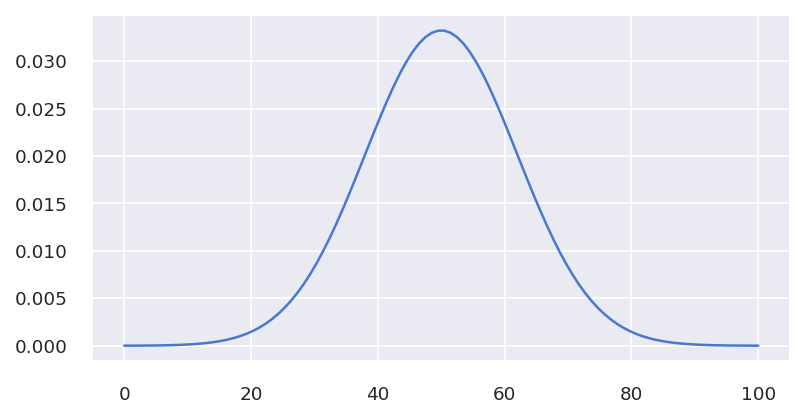

In [62]:
x = np.linspace(0, 100, 100)
y_norm = stats.norm.pdf(x, loc= 50, scale = 12)

sns.lineplot(x=x, y=y_norm, );

In [63]:
from sklearn.datasets import make_classification

# Create a synthetic classification dataset
X, y = make_classification(n_samples=10_000, n_features=5, n_classes=2, )

# Convert to DataFrame to see it clearly
df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(5)])
df['target'] = y

df

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,target
0,-0.256681,-1.312234,0.653375,1.892417,-0.161162,1
1,-1.058818,0.985457,-0.825565,-1.015463,-1.032058,0
2,2.098200,-1.313644,-0.540766,1.131030,2.008483,1
3,0.303439,-0.789112,-0.787579,0.989612,0.324853,1
4,-0.193246,-0.873716,1.944221,1.267257,-0.127890,1
...,...,...,...,...,...,...
9995,1.798886,-1.368389,0.038072,1.303530,1.735866,1
9996,-1.203239,-0.322309,-1.907170,0.834404,-1.090051,1
9997,0.148933,-1.241590,0.053131,1.663538,0.208477,1
9998,0.226392,-0.680092,-1.604827,0.864277,0.247612,1


In [64]:
df.describe()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.009022,0.009959,-0.008535,-0.010806,-0.008884,0.500100
std,1.245796,0.979908,0.989830,1.225261,1.173945,0.500025
min,-5.613281,-3.326784,-3.820131,-4.075930,-5.350878,0.000000
25%,-1.024740,-0.844694,-0.672182,-1.021127,-0.968588,0.000000
50%,0.139726,0.053774,-0.022578,0.014206,0.170895,1.000000
75%,1.004410,0.824990,0.653107,1.006489,0.909142,1.000000
max,3.808171,3.124400,3.772986,3.812313,3.595731,1.000000


In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis='columns' ), df.target,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Essential for classification!
)

In [66]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8000, 5), (8000,), (2000, 5), (2000,))

In [67]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit( X_train, y_train )

LogisticRegression(max_iter=1000)

In [68]:
y_ = model.predict( X_test )

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


In [70]:
print(classification_report( y_test, y_ ))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1000
           1       0.95      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



---

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.svm import SVC

# Define the models you want to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True)

}

In [72]:
results = []

for name, model in models.items():
    # 1. Fit the model
    model.fit(X_train, y_train)

    # 2. Make predictions
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] # For AUC

    # 3. Calculate metrics
    accuracy = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    # 4. Save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "AUC-ROC": auc
    })

# Convert results list to a DataFrame for easy comparison
comparison_df = pd.DataFrame(results).sort_values(by="AUC-ROC", ascending=False)

In [73]:
comparison_df

,Model,Accuracy,AUC-ROC
1,Random Forest,0.9885,0.997390
2,XGBoost,0.9890,0.996755
3,SVM,0.9775,0.994842
0,Logistic Regression,0.9555,0.988799


---

In [74]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        activation='relu',
        solver='adam',
        random_state=RANDOM_STATE
    ))
])

# 2. Fit and Predict
mlp_pipe.fit(X_train, y_train)
y_pred = mlp_pipe.predict(X_test)

In [75]:
print(classification_report(y_pred= y_pred, y_true= y_test))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1000
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [136]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(
    n_samples=10_000,      # More data points
    n_features=10,      # 10 total columns
    n_informative=4,    # Only 4 columns actually matter
    noise=1.0,         # High noise makes R2 < 1.0
    effective_rank=2,   # Makes features correlate with each other
    tail_strength=0.8,  # Controls the "fatness" of the tails
    coef=True,          # Returns the underlying "truth" coefficients
    random_state=RANDOM_STATE
)

df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(10)])
df['target'] = y

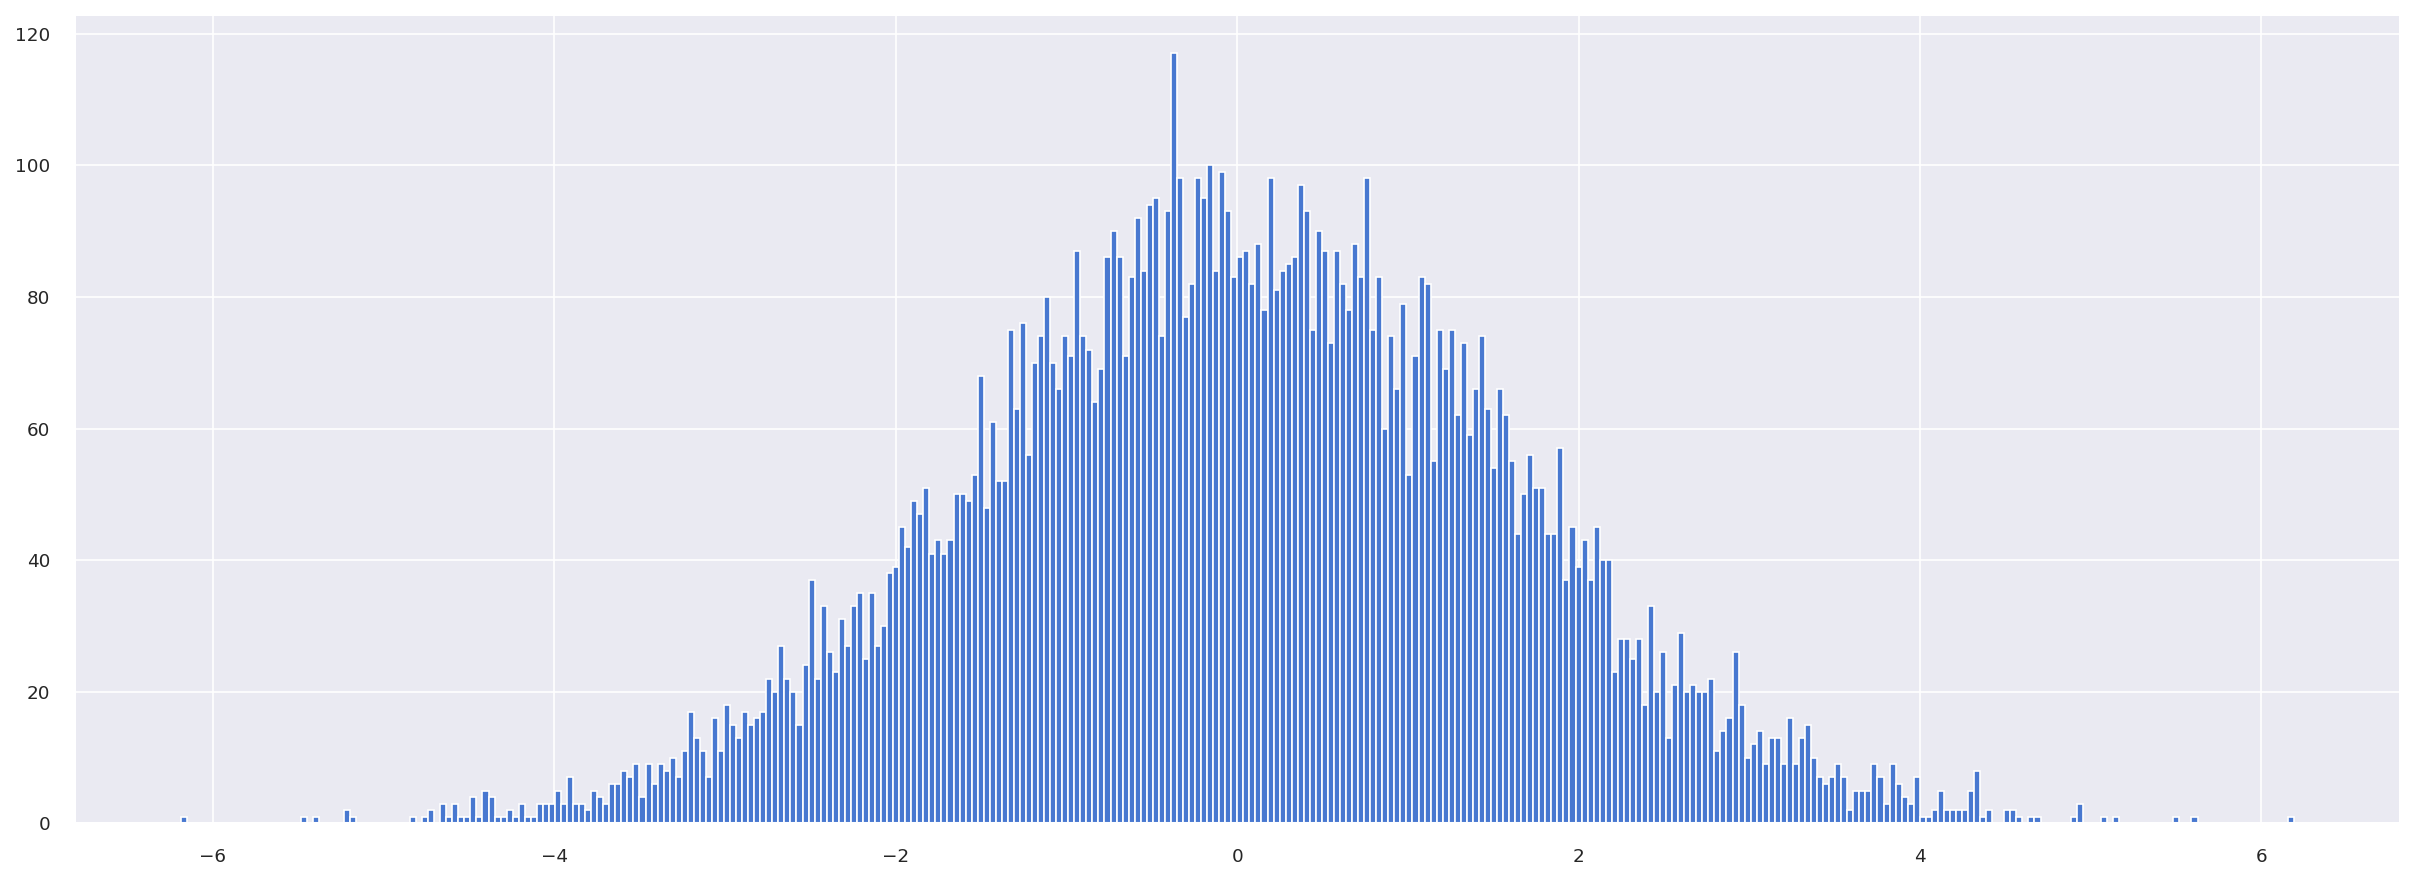

In [137]:

df.target.hist(bins=350, figsize=(20,7));

In [138]:

df

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,target
0,-0.007701,-0.009979,0.000288,-0.003012,0.005891,-0.004464,0.012655,0.002384,-0.001878,0.004273,1.601557
1,0.005645,0.000543,-0.013651,0.007167,-0.003963,-0.003664,-0.012854,0.005281,0.004312,-0.009099,-0.710769
2,0.000657,-0.000977,0.004654,0.001759,-0.000537,-0.010183,0.003516,-0.004085,-0.007850,0.005523,0.346783
3,0.007344,0.013913,-0.017241,0.003973,0.000575,0.002323,-0.015646,0.001618,0.003567,-0.008010,-0.715141
4,-0.007536,-0.006425,-0.002033,0.004514,0.006616,0.011633,-0.003070,0.005383,-0.004267,0.000857,-0.149998
...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.004851,-0.013124,-0.001127,-0.004493,-0.000305,-0.006277,0.005173,0.001143,0.005140,0.007272,0.896715
9996,-0.012494,-0.011553,0.014424,-0.001253,0.003123,-0.000068,0.005471,0.004253,0.003421,0.002729,1.315906
9997,0.015524,0.007731,-0.004358,0.000388,-0.006633,0.004095,-0.002156,-0.005203,-0.001799,0.003506,-0.708325
9998,-0.008562,0.000254,0.022128,-0.005559,0.003922,-0.008006,0.002864,-0.007889,0.001288,0.004561,1.413506


In [139]:


X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis='columns' ), df.target,
    test_size=0.2,
    random_state=RANDOM_STATE)

In [140]:


X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8000, 10), (8000,), (2000, 10), (2000,))

In [141]:
from sklearn.linear_model import LinearRegression, Ridge

model = LinearRegression()
model.fit(X_train, y_train)
y_ = model.predict(X_test)

In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_)
mse = mean_squared_error(y_test, y_)
r2 = r2_score(y_test, y_)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

MAE: 0.80
MSE: 1.00
R2: 0.56


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


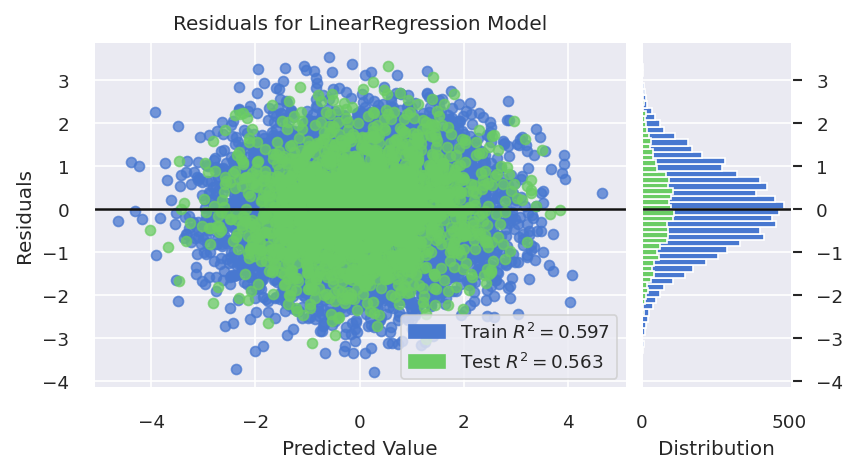

In [143]:
from yellowbrick.regressor import ResidualsPlot
visualizer = ResidualsPlot(model)

visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show();